# The Chosen Dataset
- We chose a dataset from the Stack Overflow Developer Survey, which contains information about developers worldwide such as experience, education, job roles, technologies used, and salaries. It is used to analyze trends in the software engineering field and understand factors affecting developers’ careers.

- Source: https://survey.stackoverflow.co/


# Task 1: Exploratory Data Analysis & Visualization

- Imports

In [263]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

- Read data
- Select most important features

In [264]:
df = pd.read_csv('stackoverflow_survey.csv')
# df = df.sample(n=10000, random_state=42)
df = df[['Age', 'EdLevel', 'Employment', 'WorkExp',
        'LearnCode', 'YearsCode', 'DevType', 'OrgSize',
        'RemoteWork', 'Industry', 'AIThreat', 'NewRole',
        'AISelect', 'AISent', 'Country', 
        'LanguageAdmired', 'ConvertedCompYearly', 'JobSat']]

# LearnCode, YearsCode, LanguageAdmired ==> Tech Score (Bonus)
# AIThreat, newRule, aiSelect, AiSent ==> Ai Score (Bonus)

C:\Users\kareem\AppData\Local\Temp\ipykernel_23668\1970156744.py:1: DtypeWarning: Columns (0: ResponseId, 1: DevEnvHaveEntry, 2: SOTagsHaveEntry, 3: SOTagsWant Entry, 4: CommPlatformHaveEntr, 5: CommPlatformWantEntr, 6: AIAgentOrchestration, 7: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('stackoverflow_survey.csv')


In [265]:
df.sample(20)

,Age,EdLevel,Employment,WorkExp,LearnCode,YearsCode,DevType,OrgSize,RemoteWork,Industry,AIThreat,NewRole,AISelect,AISent,Country,LanguageAdmired,ConvertedCompYearly,JobSat
47060,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11639,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,6.0,Online Courses or Certification (includes all ...,9.0,"Developer, embedded applications or devices","1,000 to 4,999 employees","Hybrid (some remote, leans heavy to in-person)",Software Development,I'm not sure,I have somewhat considered changing my career ...,"Yes, I use AI tools daily",Favorable,Poland,Assembly;Bash/Shell (all shells);C;C++;MicroPy...,29473.0,8.0
29785,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Student,6.0,"Other online resources (e.g. standard search, ...",8.0,Student,"Just me - I am a freelancer, sole proprietor, ...","Your choice (very flexible, you can come in wh...",Software Development,No,I have somewhat considered changing my career ...,"Yes, I use AI tools daily",Very favorable,China,NaN,NaN,3.0
23559,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,15.0,Technical documentation (is generated for/by t...,15.0,Data scientist,20 to 99 employees,Remote,Computer Systems Design and Services,No,I have strongly considered changing my career ...,NaN,NaN,NaN,NaN,NaN,9.0
6861,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Student,NaN,Videos (not associated with specific online co...,NaN,Student,NaN,NaN,NaN,Yes,I have neither consider or transitioned into a...,"Yes, I use AI tools daily",NaN,India,Bash/Shell (all shells);Python,NaN,NaN
39889,25-34 years old,Some college/university study without earning ...,Employed,3.0,"Other online resources (e.g. standard search, ...",8.0,"Developer, full-stack",Less than 20 employees,"Your choice (very flexible, you can come in wh...",Healthcare,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42269,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Student,NaN,Videos (not associated with specific online co...,1.0,Student,NaN,NaN,NaN,No,I have neither consider or transitioned into a...,"Yes, I use AI tools daily",Very favorable,Bangladesh,Bash/Shell (all shells);C;C++;HTML/CSS;JavaScr...,NaN,NaN
16908,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,10.0,Online Courses or Certification (includes all ...,15.0,Data scientist,Less than 20 employees,"Hybrid (some remote, leans heavy to in-person)",Software Development,Yes,I have somewhat considered changing my career ...,"Yes, I use AI tools weekly",Favorable,Italy,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,40605.0,8.0
48613,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,8.0,Technical documentation (is generated for/by t...,15.0,"Developer, back-end","1,000 to 4,999 employees",Remote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10451,18-24 years old,Some college/university study without earning ...,Not employed,5.0,Online Courses or Certification (includes all ...,10.0,Project manager,Less than 20 employees,"Your choice (very flexible, you can come in wh...",Media & Advertising Services,No,I have transitioned into a new career and/or i...,"Yes, I use AI tools monthly or infrequently",Favorable,United States of America,NaN,NaN,NaN


In [266]:
df.dtypes

Age                        str
EdLevel                    str
Employment                 str
WorkExp                float64
LearnCode                  str
YearsCode              float64
DevType                    str
OrgSize                    str
RemoteWork                 str
Industry                   str
AIThreat                   str
NewRole                    str
AISelect                   str
AISent                     str
Country                    str
LanguageAdmired            str
ConvertedCompYearly    float64
JobSat                 float64
dtype: object

In [267]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49196 entries, 0 to 49195
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  49190 non-null  str    
 1   EdLevel              48148 non-null  str    
 2   Employment           48338 non-null  str    
 3   WorkExp              42892 non-null  float64
 4   LearnCode            33556 non-null  str    
 5   YearsCode            43041 non-null  float64
 6   DevType              43679 non-null  str    
 7   OrgSize              34177 non-null  str    
 8   RemoteWork           33779 non-null  str    
 9   Industry             33641 non-null  str    
 10  AIThreat             36077 non-null  str    
 11  NewRole              35526 non-null  str    
 12  AISelect             33719 non-null  str    
 13  AISent               33466 non-null  str    
 14  Country              35436 non-null  str    
 15  LanguageAdmired      23469 non-null  str    
 1

In [268]:
df.describe()

,WorkExp,YearsCode,ConvertedCompYearly,JobSat
count,42892.000000,43041.000000,2.394600e+04,26669.000000
mean,13.367551,16.571037,1.017630e+05,7.201845
std,10.800199,11.787691,4.617665e+05,1.997209
min,1.000000,1.000000,1.000000e+00,0.000000
25%,5.000000,8.000000,3.817100e+04,6.000000
50%,10.000000,14.000000,7.532000e+04,8.000000
75%,20.000000,24.000000,1.205980e+05,8.000000
max,100.000000,100.000000,5.000000e+07,10.000000


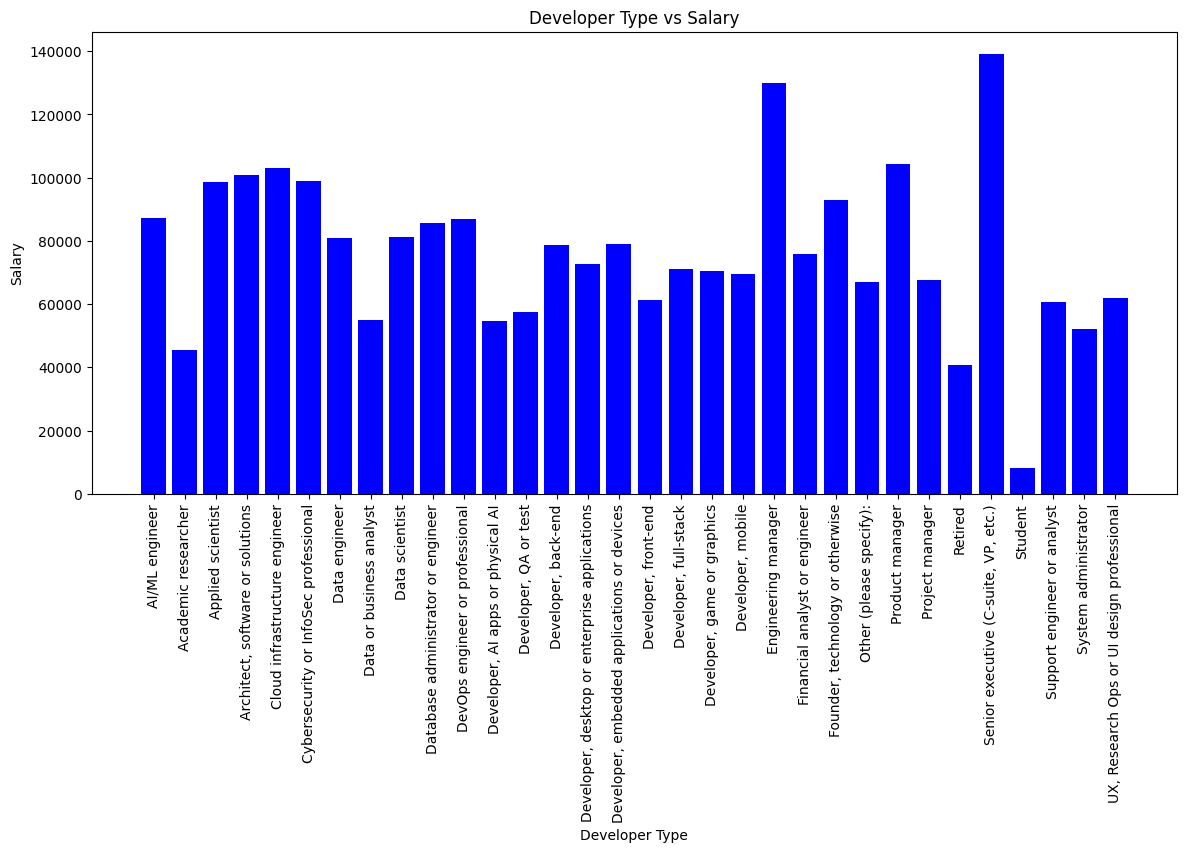

In [269]:
plt.figure(figsize=(14,6))
salaryByType = df.groupby('DevType')['ConvertedCompYearly'].median()
plt.bar(salaryByType.index, salaryByType.values, color="blue")
plt.title("Developer Type vs Salary")
plt.xlabel("Developer Type")
plt.xticks(rotation=90)
plt.ylabel("Salary")
plt.show()

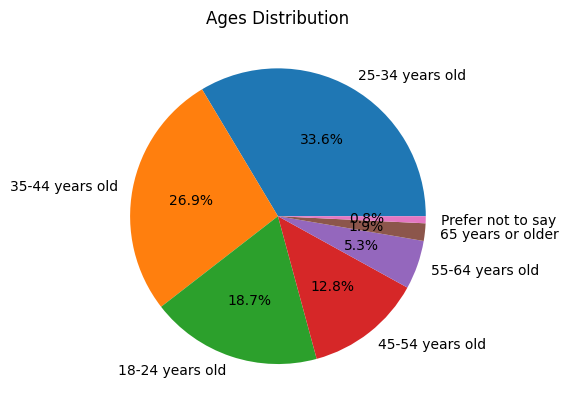

In [270]:
plt.pie(df["Age"].value_counts(), labels=df["Age"].value_counts().index, autopct="%1.1f%%")
plt.title("Ages Distribution")
plt.show()

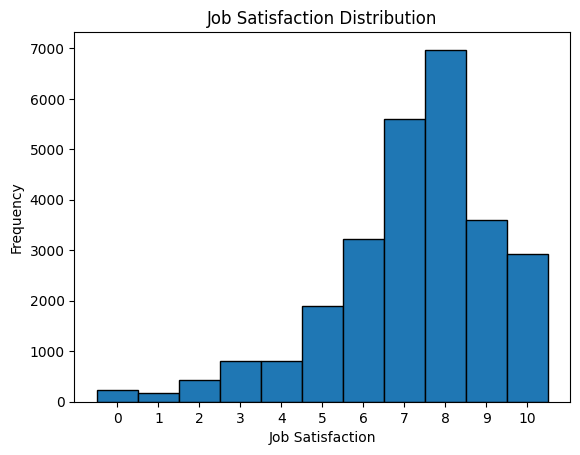

In [271]:
plt.hist(df["JobSat"], bins=np.arange(-0.5, 11.5, 1), edgecolor='black')
plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction")
plt.ylabel("Frequency")
plt.xticks(range(11))
plt.show()

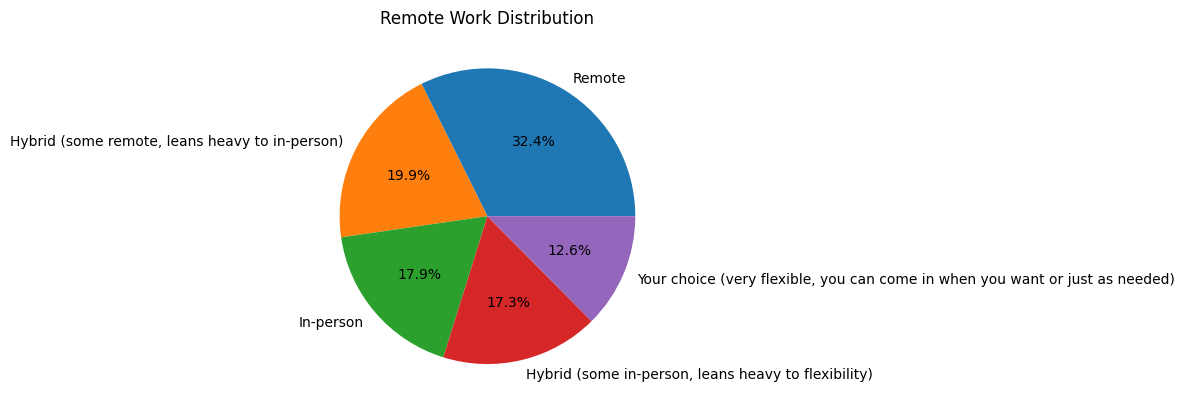

In [272]:
plt.pie(df["RemoteWork"].value_counts(), labels=df["RemoteWork"].value_counts().index, autopct="%1.1f%%")
plt.title("Remote Work Distribution")
plt.show()

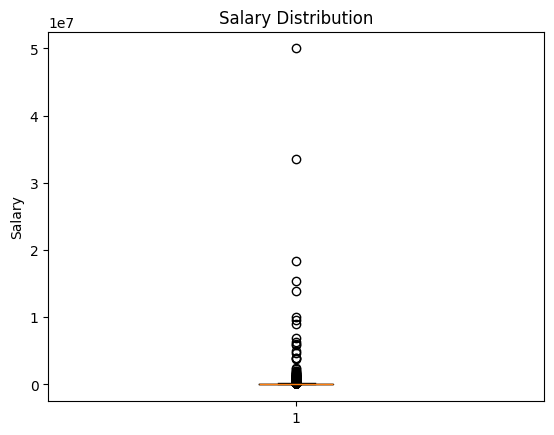

In [273]:
plt.boxplot(df["ConvertedCompYearly"].dropna())
plt.title("Salary Distribution")
plt.ylabel("Salary")
plt.show()

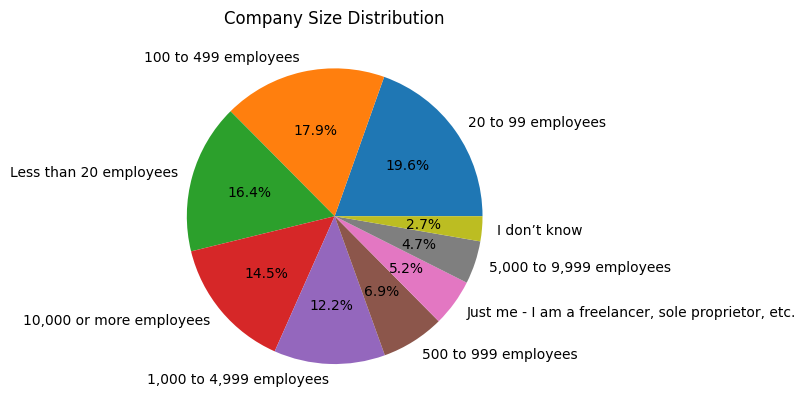

In [274]:
plt.pie(df["OrgSize"].value_counts(), labels=df["OrgSize"].value_counts().index, autopct="%1.1f%%")
plt.title("Company Size Distribution")
plt.show()

# Task 2: Data Preprocessing 

### Remove duplicate rows

In [275]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())



2923
0


### Handle missing values

In [276]:
df.isnull().sum()

Age                        1
EdLevel                  174
Employment                 8
WorkExp                 4310
LearnCode              12759
YearsCode               3249
DevType                 2609
OrgSize                12100
RemoteWork             12498
Industry               12632
AIThreat               10196
NewRole                10747
AISelect               12554
AISent                 12807
Country                10837
LanguageAdmired        22804
ConvertedCompYearly    22327
JobSat                 19604
dtype: int64

In [277]:
# Numerical Columns (Median)
num_cols = ['WorkExp', 'YearsCode', "ConvertedCompYearly", 'JobSat']

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Categories Columns (Mod)
cat_cols = ['Age', 'EdLevel', 'Employment', 'LearnCode', 'DevType', 'OrgSize', 'RemoteWork', 'Industry' , 'AIThreat', 'NewRole', 'AISelect', 'AISent', 'Country', 'LanguageAdmired']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)


In [278]:
df.isnull().sum()

Age                    0
EdLevel                0
Employment             0
WorkExp                0
LearnCode              0
YearsCode              0
DevType                0
OrgSize                0
RemoteWork             0
Industry               0
AIThreat               0
NewRole                0
AISelect               0
AISent                 0
Country                0
LanguageAdmired        0
ConvertedCompYearly    0
JobSat                 0
dtype: int64

### Detecting and treating outliers

IQR outliers in ConvertedCompYearly: 20671


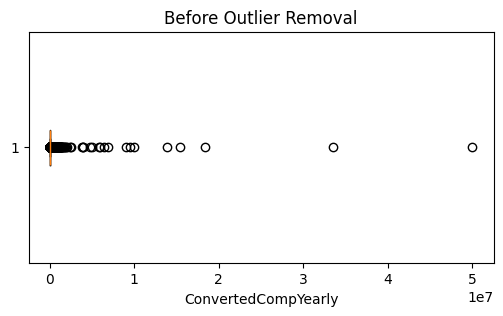

Remaining rows after trimming: 46273


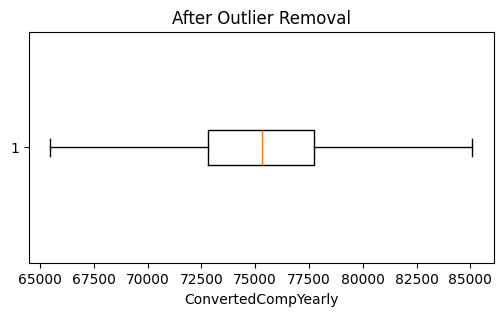

In [279]:
col = "ConvertedCompYearly"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f'IQR outliers in {col}: {len(outliers_iqr)}')

# Before plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('Before Outlier Removal')
plt.xlabel(col)
plt.show()

# Remove outliers properly

# df = df.drop(index=outliers_iqr.index)
df[col] = df[col].clip(lower_bound, upper_bound)

print(f"Remaining rows after trimming: {len(df)}")

# After plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('After Outlier Removal')
plt.xlabel(col)
plt.show()

### Encoding categorical features

- Label Encoding

In [280]:
for col in ['Age', 'EdLevel', 'OrgSize', 'AIThreat']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

- One-Hot Encoding

In [281]:
one_hot_cols = ['Employment', 'LearnCode', 'DevType', 'RemoteWork', 'Industry', 'NewRole', 'AISelect', 'AISent', 'Country', 'LanguageAdmired']

df = pd.get_dummies(df, columns=one_hot_cols)


### Feature scaling

- Standardization (z-score)

In [284]:
for col in ['WorkExp', 'YearsCode', 'ConvertedCompYearly']:
    std_scaler = StandardScaler()
    df[col] = std_scaler.fit_transform(df[[col]])